# **DecodeLab_P2_Iris_KNN_Classification**

# **Section 1: Environment Setup & Modular Data Pipeline.**

In [1]:


import logging
import os
import random
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Logging Configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

# 2. Reproducibility & Seed Setting
def set_seed(seed: int = 42) -> None:
    """Sets static seeds for numpy, random, and environment variables."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    logger.info(f"Global random seed set to: {seed}")

set_seed(42)

# 3. Modular Data Loader Class
class IrisDataPipeline:
    """Production-grade pipeline for loading, splitting, and scaling tabular datasets."""
    
    def __init__(self, test_size: float = 0.2, random_state: int = 42):
        self.test_size = test_size
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.feature_names = []
        self.target_names = []
        
    def load_and_preprocess(self):
        """Loads dataset, converts to pandas DataFrame, splits, and scales data safely."""
        logger.info("Loading Iris benchmark dataset...")
        raw_data = load_iris()
        
        self.feature_names = raw_data.feature_names
        self.target_names = raw_data.target_names
        
        df = pd.DataFrame(data=raw_data.data, columns=self.feature_names)
        df['target'] = raw_data.target
        
        X = df[self.feature_names]
        y = df['target']
        
        # Stratified Train-Test Split (Preserves class proportions)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, 
            test_size=self.test_size, 
            random_state=self.random_state, 
            stratify=y
        )
        logger.info(f"Data split completed. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
        
        # Fit scaler ONLY on training data to prevent Data Leakage
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        logger.info("Feature scaling applied using StandardScaler (Mean=0, Variance=1).")
        
        return {
            "X_train_scaled": X_train_scaled,
            "X_test_scaled": X_test_scaled,
            "y_train": y_train.values,
            "y_test": y_test.values,
            "df": df,
            "feature_names": self.feature_names,
            "target_names": self.target_names
        }

# Execution
pipeline = IrisDataPipeline(test_size=0.2, random_state=42)
data_dict = pipeline.load_and_preprocess()
print("\n--- Pipeline Initialized Successfully ---")
print(f"Features: {data_dict['feature_names']}")
print(f"Target Classes: {data_dict['target_names']}")

2026-07-30 05:42:54,477 [INFO] Global random seed set to: 42
2026-07-30 05:42:54,478 [INFO] Loading Iris benchmark dataset...
2026-07-30 05:42:54,503 [INFO] Data split completed. Train shape: (120, 4), Test shape: (30, 4)
2026-07-30 05:42:54,508 [INFO] Feature scaling applied using StandardScaler (Mean=0, Variance=1).



--- Pipeline Initialized Successfully ---
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes: ['setosa' 'versicolor' 'virginica']


# **SECTION 2: ADVANCED EDA & FEATURE VISUALIZATIONS**

2026-07-30 05:42:55,488 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-30 05:42:55,500 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


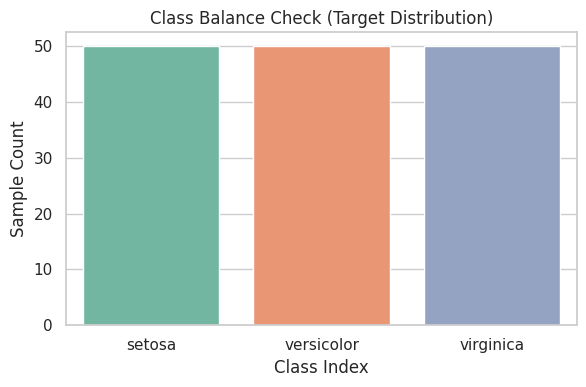

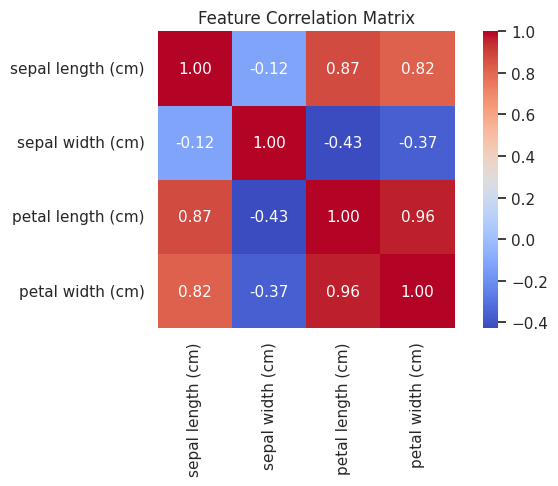

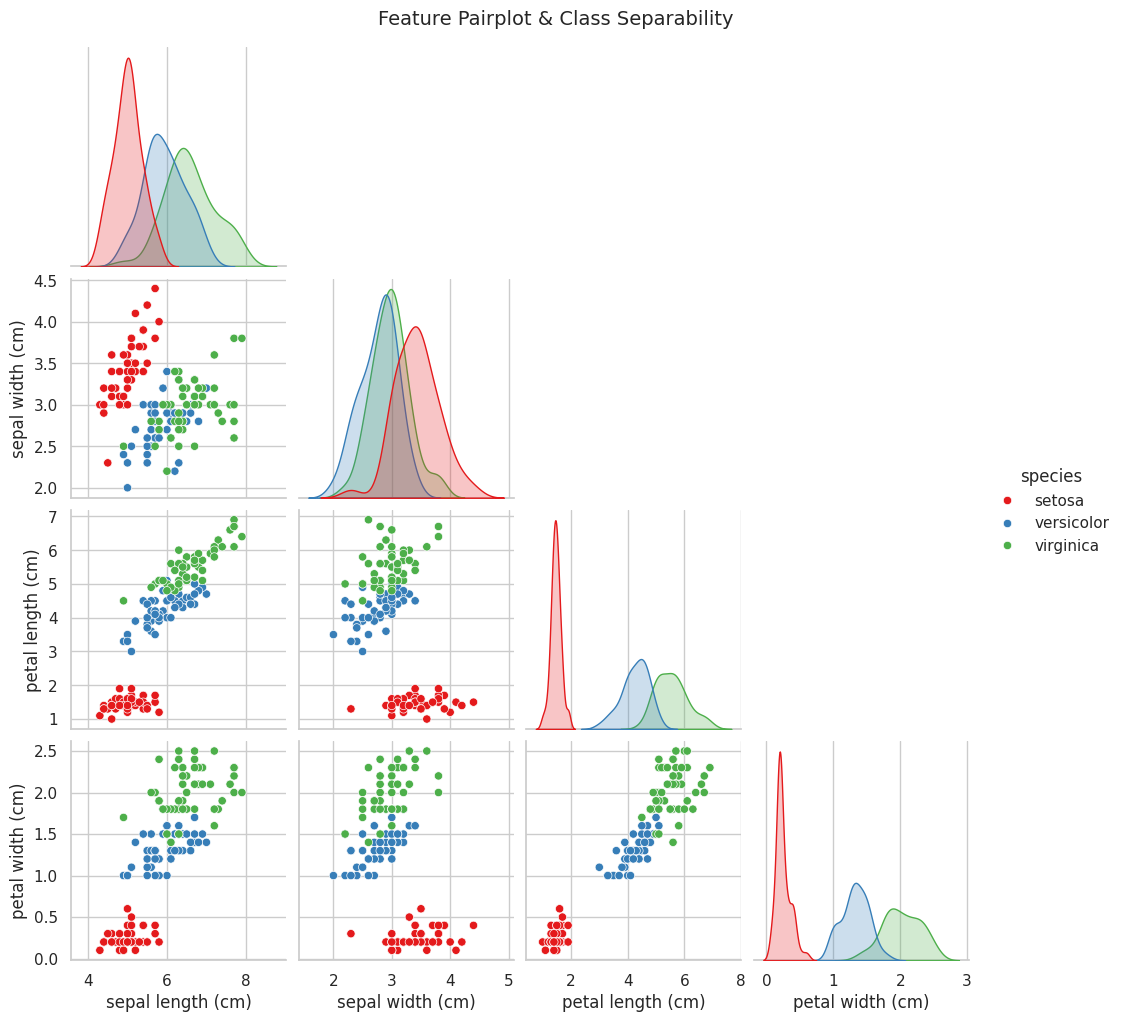

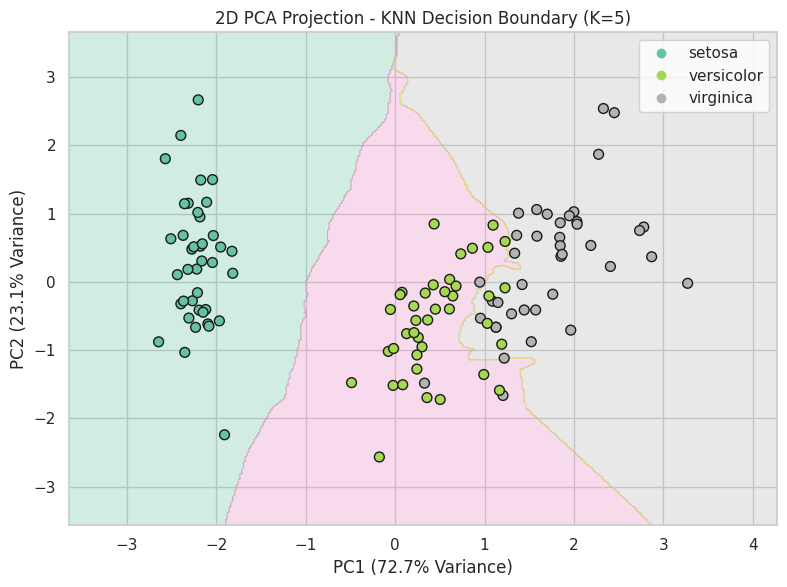

In [2]:


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# Set global visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

class IrisEDA:
    """Exploratory Data Analysis suite for feature distribution and decision surfaces."""
    
    def __init__(self, df, feature_names, target_names):
        self.df = df
        self.feature_names = feature_names
        self.target_names = target_names
        
    def plot_class_distribution(self):
        """Checks target variable balance."""
        plt.figure(figsize=(6, 4))
        ax = sns.countplot(x='target', data=self.df, hue='target', palette='Set2', legend=False)
        plt.title("Class Balance Check (Target Distribution)")
        plt.xlabel("Class Index")
        plt.ylabel("Sample Count")
        ax.set_xticks(range(len(self.target_names)))
        ax.set_xticklabels(self.target_names)
        plt.tight_layout()
        plt.show()

    def plot_correlation_heatmap(self):
        """Displays feature collinearity matrix."""
        plt.figure(figsize=(7, 5))
        corr = self.df[self.feature_names].corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
        plt.title("Feature Correlation Matrix")
        plt.tight_layout()
        plt.show()

    def plot_pairplot(self):
        """Generates pairplot showing feature separability across classes."""
        mapped_df = self.df.copy()
        mapped_df['species'] = mapped_df['target'].map(lambda x: self.target_names[x])
        g = sns.pairplot(mapped_df, vars=self.feature_names, hue='species', palette='Set1', corner=True)
        g.fig.suptitle("Feature Pairplot & Class Separability", y=1.02)
        plt.show()

    def plot_2d_decision_boundary(self, X_scaled, y, k_neighbors=5):
        """Reduces data to 2D using PCA and plots KNN decision boundaries."""
        # Reduce dimensions to 2D for surface plotting
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        # Train temporary KNN model on 2D projections
        clf_2d = KNeighborsClassifier(n_neighbors=k_neighbors)
        clf_2d.fit(X_pca, y)
        
        # Create grid coordinates
        x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
        y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        
        Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        plt.figure(figsize=(8, 6))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set2', edgecolor='k', s=50)
        
        plt.title(f"2D PCA Projection - KNN Decision Boundary (K={k_neighbors})")
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
        
        handles, _ = scatter.legend_elements()
        plt.legend(handles, self.target_names, loc="upper right")
        plt.tight_layout()
        plt.show()

# Execution
eda = IrisEDA(data_dict['df'], data_dict['feature_names'], data_dict['target_names'])
eda.plot_class_distribution()
eda.plot_correlation_heatmap()
eda.plot_pairplot()
eda.plot_2d_decision_boundary(data_dict['X_train_scaled'], data_dict['y_train'], k_neighbors=5)

# **SECTION 3: MODEL TRAINING, ELBOW CURVE & HYPERPARAMETER GRID SEARCH**

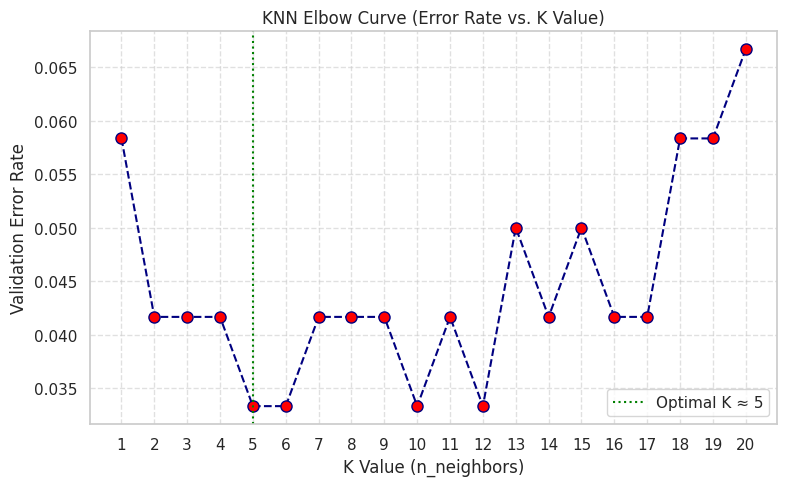

Fitting 5 folds for each of 120 candidates, totalling 600 fits

--- Grid Search Optimization Complete ---
Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Best 5-Fold Cross-Validation F1-Score: 0.9747


In [3]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

class KNNTrainer:
    """Class to handle KNN tuning via Elbow Method and Cross-Validated Grid Search."""
    
    def __init__(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        self.best_model = None
        self.best_params = None

    def plot_elbow_curve(self, max_k: int = 20):
        """
        Calculates error rate across various K values and plots the Elbow Curve.
        Helps diagnose Overfitting (low K) vs Underfitting (high K).
        """
        error_rates = []
        k_range = range(1, max_k + 1)
        
        for k in k_range:
            knn = KNeighborsClassifier(n_neighbors=k)
            # Use 5-fold cross-validation score
            scores = cross_val_score(knn, self.X_train, self.y_train, cv=5, scoring='accuracy')
            error_rates.append(1 - scores.mean())
            
        plt.figure(figsize=(8, 5))
        plt.plot(k_range, error_rates, color='navy', linestyle='dashed', marker='o',
                 markerfacecolor='red', markersize=8)
        plt.title('KNN Elbow Curve (Error Rate vs. K Value)')
        plt.xlabel('K Value (n_neighbors)')
        plt.ylabel('Validation Error Rate')
        plt.xticks(k_range)
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Highlight optimal K range
        min_error_k = k_range[np.argmin(error_rates)]
        plt.axvline(x=min_error_k, color='green', linestyle=':', label=f'Optimal K ≈ {min_error_k}')
        plt.legend()
        plt.tight_layout()
        plt.show()

    def run_grid_search(self):
        """Executes Stratified 5-Fold Cross-Validated Grid Search over hyperparameters."""
        param_grid = {
            'n_neighbors': list(range(1, 21)),
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']
        }
        
        grid_search = GridSearchCV(
            estimator=KNeighborsClassifier(),
            param_grid=param_grid,
            cv=5,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(self.X_train, self.y_train)
        
        self.best_model = grid_search.best_estimator_
        self.best_params = grid_search.best_params_
        
        print("\n--- Grid Search Optimization Complete ---")
        print(f"Best Hyperparameters: {self.best_params}")
        print(f"Best 5-Fold Cross-Validation F1-Score: {grid_search.best_score_:.4f}")
        
        return self.best_model, self.best_params

# Execution
trainer = KNNTrainer(data_dict['X_train_scaled'], data_dict['y_train'])

# 1. Visualize Elbow Curve
trainer.plot_elbow_curve(max_k=20)

# 2. Execute Systematic Grid Search
best_knn_model, best_params = trainer.run_grid_search()

# **SECTION 4: MULTI-MODEL BENCHMARKING & METRIC EVALUATION**


--- MODEL BENCHMARK SUMMARY TABLE ---
                       Model Accuracy Precision (Macro) Recall (Macro) F1-Score (Macro) Fit Latency (s)
             KNN (Optimized)   0.9667            0.9697         0.9667           0.9666        0.000001
         Logistic Regression   0.9333            0.9333         0.9333           0.9333        0.009026
               Random Forest   0.9000            0.9024         0.9000           0.8997        0.179058
Support Vector Machine (SVM)   0.9667            0.9697         0.9667           0.9666        0.004826


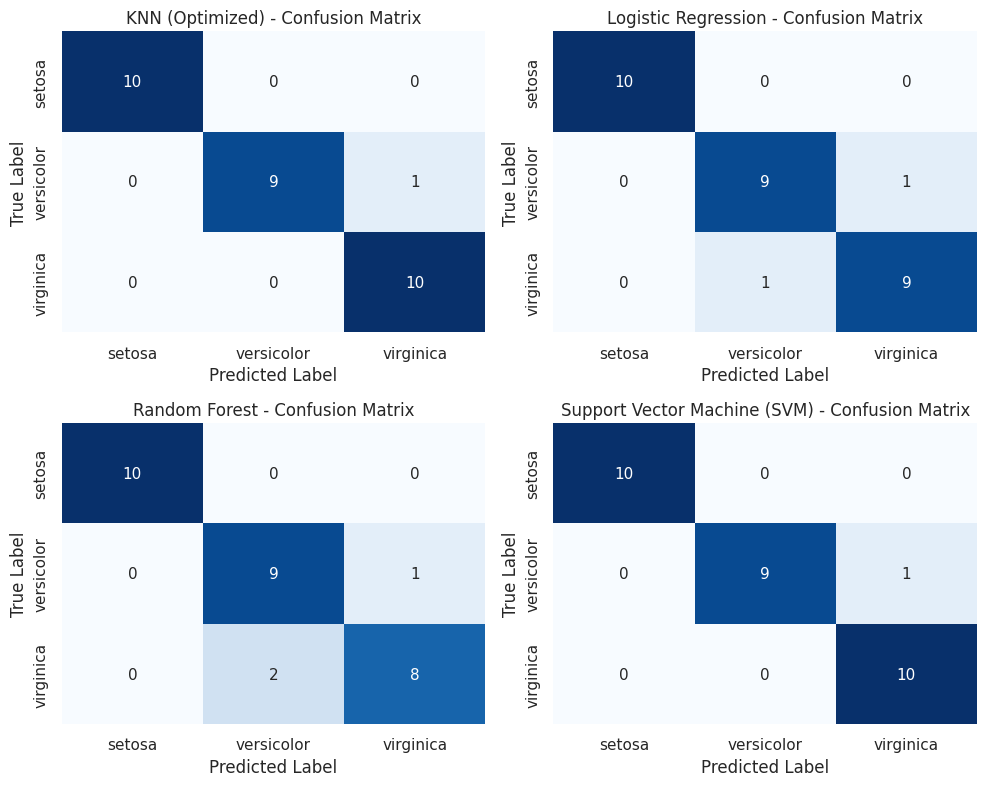


--- DETAILED CLASSIFICATION REPORT (OPTIMIZED KNN) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [4]:


import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

class ModelBenchmark:
    """Evaluates and compares multiple ML classifiers on test data."""
    
    def __init__(self, X_train, y_train, X_test, y_test, target_names):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.target_names = target_names
        self.results = {}

    def run_benchmark(self, best_knn_model):
        """Trains multiple candidate models and benchmarks performance metrics."""
        models = {
            "KNN (Optimized)": best_knn_model,
            "Logistic Regression": LogisticRegression(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "Support Vector Machine (SVM)": SVC(probability=True, random_state=42)
        }
        
        benchmark_list = []
        
        for name, model in models.items():
            start_time = time.time()
            if name != "KNN (Optimized)":
                model.fit(self.X_train, self.y_train)
            train_time = time.time() - start_time
            
            y_pred = model.predict(self.X_test)
            
            acc = accuracy_score(self.y_test, y_pred)
            prec = precision_score(self.y_test, y_pred, average='macro')
            rec = recall_score(self.y_test, y_pred, average='macro')
            f1 = f1_score(self.y_test, y_pred, average='macro')
            
            self.results[name] = {
                "model": model,
                "y_pred": y_pred,
                "metrics": {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
            }
            
            benchmark_list.append({
                "Model": name,
                "Accuracy": f"{acc:.4f}",
                "Precision (Macro)": f"{prec:.4f}",
                "Recall (Macro)": f"{rec:.4f}",
                "F1-Score (Macro)": f"{f1:.4f}",
                "Fit Latency (s)": f"{train_time:.6f}"
            })
            
        benchmark_df = pd.DataFrame(benchmark_list)
        return benchmark_df

    def plot_confusion_matrices(self):
        """Plots confusion matrices for all evaluated models side-by-side."""
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        axes = axes.flatten()
        
        for idx, (name, data) in enumerate(self.results.items()):
            cm = confusion_matrix(self.y_test, data["y_pred"])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                        xticklabels=self.target_names, yticklabels=self.target_names, cbar=False)
            axes[idx].set_title(f"{name} - Confusion Matrix")
            axes[idx].set_xlabel("Predicted Label")
            axes[idx].set_ylabel("True Label")
            
        plt.tight_layout()
        plt.show()

# Execution
benchmark = ModelBenchmark(
    data_dict['X_train_scaled'], data_dict['y_train'],
    data_dict['X_test_scaled'], data_dict['y_test'],
    data_dict['target_names']
)

# 1. Run Comparative Evaluation
results_df = benchmark.run_benchmark(best_knn_model)
print("\n--- MODEL BENCHMARK SUMMARY TABLE ---")
print(results_df.to_string(index=False))

# 2. Plot Confusion Matrices
benchmark.plot_confusion_matrices()

# 3. Output Detailed Classification Report for Best KNN Model
print("\n--- DETAILED CLASSIFICATION REPORT (OPTIMIZED KNN) ---")
print(classification_report(data_dict['y_test'], benchmark.results["KNN (Optimized)"]["y_pred"], 
                            target_names=data_dict['target_names']))

# **SECTION 5: INFERENCE PIPELINE & ARTIFACT PERSISTENCE**

In [5]:


import os
import joblib
import numpy as np
import pandas as pd

class ModelInferenceEngine:
    """Production wrapper to persist artifacts and serve raw feature predictions."""
    
    def __init__(self, artifact_dir: str = "./artifacts"):
        self.artifact_dir = artifact_dir
        os.makedirs(self.artifact_dir, exist_ok=True)
        self.scaler_path = os.path.join(self.artifact_dir, "standard_scaler.joblib")
        self.model_path = os.path.join(self.artifact_dir, "knn_model.joblib")
        
        self.scaler = None
        self.model = None

    def save_artifacts(self, scaler, model):
        """Persists fitted scaler and trained model to disk."""
        joblib.dump(scaler, self.scaler_path)
        joblib.dump(model, self.model_path)
        print(f"Artifacts successfully saved to folder: '{self.artifact_dir}'")

    def load_artifacts(self):
        """Loads saved scaler and model artifacts from disk."""
        if not os.path.exists(self.scaler_path) or not os.path.exists(self.model_path):
            raise FileNotFoundError("Model or Scaler artifact not found on disk.")
            
        self.scaler = joblib.load(self.scaler_path)
        self.model = joblib.load(self.model_path)
        print("Model and Scaler artifacts successfully loaded into memory.")

    def predict_single_sample(self, raw_features: list, feature_names: list, target_names: list) -> dict:
        """
        Preprocesses a raw, unscaled feature vector and runs inference.
        
        Args:
            raw_features: List of 4 floats [sepal_length, sepal_width, petal_length, petal_width]
            feature_names: List of feature names
            target_names: List of species class labels
            
        Returns:
            Dictionary containing predicted class, label name, and class confidence probabilities.
        """
        if self.scaler is None or self.model is None:
            self.load_artifacts()

        # Convert to 2D numpy array/DataFrame
        input_df = pd.DataFrame([raw_features], columns=feature_names)
        
        # Scale features using the SAVED train scaler
        scaled_input = self.scaler.transform(input_df)
        
        # Predict class index and probabilities
        pred_idx = int(self.model.predict(scaled_input)[0])
        probabilities = self.model.predict_proba(scaled_input)[0]
        
        predicted_class_name = target_names[pred_idx]
        
        confidence_dict = {
            target_names[i]: float(probabilities[i]) for i in range(len(target_names))
        }
        
        return {
            "predicted_class_index": pred_idx,
            "predicted_species": predicted_class_name,
            "confidence_probabilities": confidence_dict
        }

# Execution
# 1. Instantiate and Save Pipeline Artifacts
engine = ModelInferenceEngine(artifact_dir="./knn_iris_artifacts")
engine.save_artifacts(scaler=pipeline.scaler, model=best_knn_model)

# 2. Simulate Production Inference with Raw Sample Inputs
# Sample raw input representing a typical Setosa flower: [Sepal Length, Sepal Width, Petal Length, Petal Width]
sample_raw_features = [5.1, 3.5, 1.4, 0.2]

print("\n--- RUNNING INFERENCE ON NEW RAW SAMPLE ---")
print(f"Input Raw Sample Features: {dict(zip(data_dict['feature_names'], sample_raw_features))}")

prediction = engine.predict_single_sample(
    raw_features=sample_raw_features,
    feature_names=data_dict['feature_names'],
    target_names=data_dict['target_names']
)

print(f"\nPredicted Species: {prediction['predicted_species'].upper()}")
print("Class Probabilities:")
for species, prob in prediction['confidence_probabilities'].items():
    print(f"  - {species.capitalize()}: {prob * 100:.2f}%")

Artifacts successfully saved to folder: './knn_iris_artifacts'

--- RUNNING INFERENCE ON NEW RAW SAMPLE ---
Input Raw Sample Features: {'sepal length (cm)': 5.1, 'sepal width (cm)': 3.5, 'petal length (cm)': 1.4, 'petal width (cm)': 0.2}
Model and Scaler artifacts successfully loaded into memory.

Predicted Species: SETOSA
Class Probabilities:
  - Setosa: 100.00%
  - Versicolor: 0.00%
  - Virginica: 0.00%
